# European Flight Network Analysis

**Algorithms in Networks – Final Project**

**Submitted by:** Shiri Weiss, Lior Ben Yehuda, Adir Ben Dayan

This notebook analyzes the structural properties of the European flight
network using centrality measures, local clustering, community detection,
and robustness experiments.

## 1. Imports and Setup

In this section, we import the Python libraries required for data processing, graph construction, and visualization.

In [ ]:
!pip install -q networkx pandas matplotlib python-louvain

In [ ]:
import random
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import community.community_louvain as community_louvain

## 2. Loading the Dataset

We use the OpenFlights dataset, which contains information about airports and flight routes.

Two files are used:
- airports.dat: contains airport metadata such as airport ID, name, city, country, IATA code, and coordinates.
- routes.dat: contains flight route information, including source airport and destination airport.

The data is loaded directly from public URLs, so the notebook can run without requiring manual file downloads.

In [ ]:
airports_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
routes_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat"

airport_cols = [
    "airport_id",
    "name",
    "city",
    "country",
    "iata",
    "icao",
    "latitude",
    "longitude",
    "altitude",
    "timezone",
    "dst",
    "tz_database_time_zone",
    "type",
    "source"
]

route_cols = [
    "airline",
    "airline_id",
    "source_airport",
    "source_airport_id",
    "destination_airport",
    "destination_airport_id",
    "codeshare",
    "stops",
    "equipment"
]

airports = pd.read_csv(
    airports_url,
    header=None,
    names=airport_cols,
    na_values="\\N"
)

routes = pd.read_csv(
    routes_url,
    header=None,
    names=route_cols,
    na_values="\\N"
)

## 3. Initial Data Exploration

Before filtering the data, we inspect the structure of both datasets.
We check the number of rows and columns, the available attributes, and the country names used in the airport table.

In [ ]:
display(airports.head())
display(routes.head())

print("Airports shape:", airports.shape)
print("Routes shape:", routes.shape)

print("\nAirports columns:")
print(airports.columns)

print("\nRoutes columns:")
print(routes.columns)

,airport_id,name,city,country,iata,icao,latitude,longitude,altitude,timezone,dst,tz_database_time_zone,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10.0,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10.0,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10.0,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10.0,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10.0,U,Pacific/Port_Moresby,airport,OurAirports


,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment
0,2B,410.0,AER,2965.0,KZN,2990.0,NaN,0,CR2
1,2B,410.0,ASF,2966.0,KZN,2990.0,NaN,0,CR2
2,2B,410.0,ASF,2966.0,MRV,2962.0,NaN,0,CR2
3,2B,410.0,CEK,2968.0,KZN,2990.0,NaN,0,CR2
4,2B,410.0,CEK,2968.0,OVB,4078.0,NaN,0,CR2


Airports shape: (7698, 14)
Routes shape: (67663, 9)

Airports columns:
Index(['airport_id', 'name', 'city', 'country', 'iata', 'icao', 'latitude',
       'longitude', 'altitude', 'timezone', 'dst', 'tz_database_time_zone',
       'type', 'source'],
      dtype='object')

Routes columns:
Index(['airline', 'airline_id', 'source_airport', 'source_airport_id',
       'destination_airport', 'destination_airport_id', 'codeshare', 'stops',
       'equipment'],
      dtype='object')


## 4. Filtering European Airports

The original dataset contains airports from countries around the world.
Since this project focuses on Europe, a predefined list of European countries
is used to filter the airport table.

Before applying the filter, we check which countries in the predefined list
do not have airport records in the OpenFlights dataset. Their absence does not
affect the filtering process.

In [ ]:
europe_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Denmark", "Estonia", "Faroe Islands",
    "Finland", "France", "Germany", "Gibraltar", "Greece",
    "Guernsey", "Hungary", "Iceland", "Ireland", "Isle of Man",
    "Italy", "Jersey", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Macedonia", "Malta", "Moldova", "Monaco",
    "Montenegro", "Netherlands", "Norway", "Poland", "Portugal",
    "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Svalbard", "Sweden", "Switzerland",
    "Ukraine", "United Kingdom"
]

countries_without_airport_records = sorted(
    set(europe_countries) - set(airports["country"].dropna().unique())
)

print(
    "European countries with no airport records in the dataset:",
    countries_without_airport_records
)

europe_airports = airports[
    airports["country"].isin(europe_countries)
].copy()

print("European airports:", europe_airports.shape)
europe_airports.head()

European countries with no airport records in the dataset: ['Andorra', 'Liechtenstein', 'Monaco', 'San Marino']
European airports: (1508, 14)


,airport_id,name,city,country,iata,icao,latitude,longitude,altitude,timezone,dst,tz_database_time_zone,type,source
10,11,Akureyri Airport,Akureyri,Iceland,AEY,BIAR,65.660004,-18.072701,6,0.0,N,Atlantic/Reykjavik,airport,OurAirports
11,12,Egilsstaðir Airport,Egilsstadir,Iceland,EGS,BIEG,65.283302,-14.401400,76,0.0,N,Atlantic/Reykjavik,airport,OurAirports
12,13,Hornafjörður Airport,Hofn,Iceland,HFN,BIHN,64.295601,-15.227200,24,0.0,N,Atlantic/Reykjavik,airport,OurAirports
13,14,Húsavík Airport,Husavik,Iceland,HZK,BIHU,65.952301,-17.426001,48,0.0,N,Atlantic/Reykjavik,airport,OurAirports
14,15,Ísafjörður Airport,Isafjordur,Iceland,IFJ,BIIS,66.058098,-23.135300,8,0.0,N,Atlantic/Reykjavik,airport,OurAirports


## 5. Cleaning Route Data

Each route should contain a valid source airport ID and destination airport ID.
Rows with missing or invalid airport IDs cannot be represented as graph edges, so they are removed.

We also convert the airport ID columns to integers so they can be matched with the airport_id column in the airport table.

In [ ]:
routes["source_airport_id"] = pd.to_numeric(routes["source_airport_id"], errors="coerce")
routes["destination_airport_id"] = pd.to_numeric(routes["destination_airport_id"], errors="coerce")

routes_clean = routes.dropna(
    subset=["source_airport_id", "destination_airport_id"]
).copy()

routes_clean["source_airport_id"] = routes_clean["source_airport_id"].astype(int)
routes_clean["destination_airport_id"] = routes_clean["destination_airport_id"].astype(int)

print("Clean routes:", routes_clean.shape)
routes_clean.head()

Clean routes: (67240, 9)


,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment
0,2B,410.0,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410.0,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410.0,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410.0,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410.0,CEK,2968,OVB,4078,NaN,0,CR2


## 6. Filtering European Routes

After filtering the airport table, we keep only routes where both the source airport and the destination airport are located in Europe.

This ensures that the resulting graph represents flight connections inside the European flight network.

In [ ]:
europe_airport_ids = set(europe_airports["airport_id"])

europe_routes = routes_clean[
    routes_clean["source_airport_id"].isin(europe_airport_ids) &
    routes_clean["destination_airport_id"].isin(europe_airport_ids)
].copy()

print("European routes:", europe_routes.shape)
europe_routes.head()

European routes: (15224, 9)


,airline,airline_id,source_airport,source_airport_id,destination_airport,destination_airport_id,codeshare,stops,equipment
115,2L,2750.0,BDS,1506,ZRH,1678,NaN,0,100
116,2L,2750.0,BOD,1264,ZRH,1678,NaN,0,100
117,2L,2750.0,BRS,490,ZRH,1678,NaN,0,100
118,2L,2750.0,GVA,1665,LPA,1054,NaN,0,319
119,2L,2750.0,LCA,1197,ZRH,1678,NaN,0,319


## 7. Selecting Active Airports

Some European airports appear in the airport table but do not appear in any European route after filtering.
Such airports would become isolated nodes in the graph.

For the main network analysis, we use only active airports, meaning airports that appear at least once as a source or destination in the filtered European routes.

In [ ]:
active_airport_ids = set(europe_routes["source_airport_id"]).union(
    set(europe_routes["destination_airport_id"])
)

active_europe_airports = europe_airports[
    europe_airports["airport_id"].isin(active_airport_ids)
].copy()

print("All European airports:", len(europe_airports))
print("Active European airports:", len(active_europe_airports))
print("Inactive European airports:", len(europe_airports) - len(active_europe_airports))

All European airports: 1508
Active European airports: 496
Inactive European airports: 1012


## 8. Validating the Filtered Routes

To verify that the filtering process worked correctly, we join the route table with airport metadata.
This allows us to inspect the source and destination airport names, cities, and countries.

This step is mainly used for validation and interpretation, not for building the graph itself.

In [ ]:
airport_info = active_europe_airports[
    ["airport_id", "name", "city", "country", "iata", "latitude", "longitude"]
].copy()

source_info = airport_info.add_prefix("source_")
destination_info = airport_info.add_prefix("destination_")

routes_with_airports = europe_routes.merge(
    source_info,
    left_on="source_airport_id",
    right_on="source_airport_id",
    how="left"
).merge(
    destination_info,
    left_on="destination_airport_id",
    right_on="destination_airport_id",
    how="left"
)

routes_with_airports[
    [
        "source_airport", "source_name", "source_city", "source_country",
        "destination_airport", "destination_name", "destination_city", "destination_country"
    ]
].head(20)

,source_airport,source_name,source_city,source_country,destination_airport,destination_name,destination_city,destination_country
0,BDS,Brindisi – Salento Airport,Brindisi,Italy,ZRH,Zürich Airport,Zurich,Switzerland
1,BOD,Bordeaux-Mérignac Airport,Bordeaux,France,ZRH,Zürich Airport,Zurich,Switzerland
2,BRS,Bristol Airport,Bristol,United Kingdom,ZRH,Zürich Airport,Zurich,Switzerland
3,GVA,Geneva Cointrin International Airport,Geneva,Switzerland,LPA,Gran Canaria Airport,Gran Canaria,Spain
4,LCA,Larnaca International Airport,Larnaca,Cyprus,ZRH,Zürich Airport,Zurich,Switzerland
5,LPA,Gran Canaria Airport,Gran Canaria,Spain,ZRH,Zürich Airport,Zurich,Switzerland
6,TFS,Tenerife South Airport,Tenerife,Spain,GVA,Geneva Cointrin International Airport,Geneva,Switzerland
7,ZRH,Zürich Airport,Zurich,Switzerland,BDS,Brindisi – Salento Airport,Brindisi,Italy
8,ZRH,Zürich Airport,Zurich,Switzerland,BOD,Bordeaux-Mérignac Airport,Bordeaux,France
9,ZRH,Zürich Airport,Zurich,Switzerland,BRS,Bristol Airport,Bristol,United Kingdom


## 9. Building the Active European Flight Network

In this step, we construct the flight network as an undirected graph.

Graph definition:
- Node: an active European airport.
- Edge: a flight route between two active European airports.
- Edge weight: the number of route records between the same pair of airports.

We use an undirected graph in the initial analysis because we focus on general connectivity between airports rather than flight direction.

In [ ]:
G = nx.Graph()

# Add only active airport nodes
for _, row in active_europe_airports.iterrows():
    G.add_node(
        row["airport_id"],
        name=row["name"],
        city=row["city"],
        country=row["country"],
        iata=row["iata"],
        latitude=row["latitude"],
        longitude=row["longitude"]
    )

# Add route edges
for _, row in europe_routes.iterrows():
    source = row["source_airport_id"]
    target = row["destination_airport_id"]

    if G.has_edge(source, target):
        G[source][target]["weight"] += 1
    else:
        G.add_edge(source, target, weight=1)

### Degree Distribution Visualization

This visualization shows how many airports have a given number of direct connections.
It helps us identify whether the network contains hub airports with many connections.

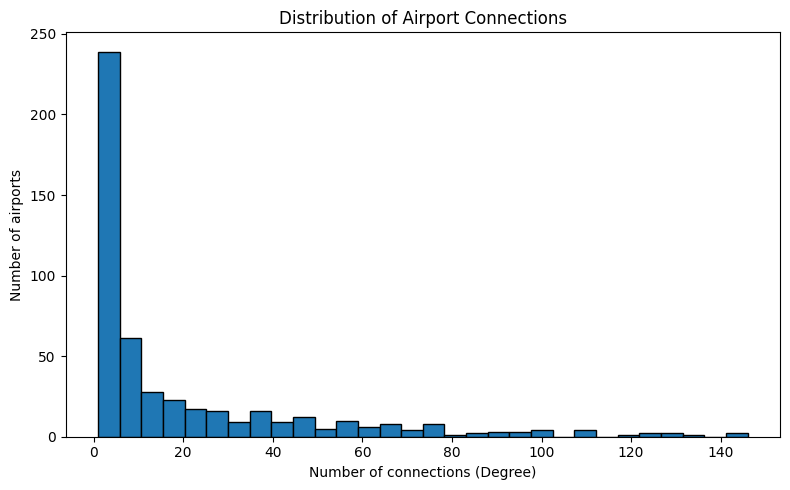

In [ ]:
degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=30, edgecolor="black")

plt.title("Distribution of Airport Connections")
plt.xlabel("Number of connections (Degree)")
plt.ylabel("Number of airports")

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=300)
plt.show()

## 10. Basic Network Statistics

We compute basic structural properties of the active flight network:

- number of nodes
- number of edges
- graph density
- average degree
- number of connected components
- size of the largest connected component

These statistics provide an initial understanding of the network structure before applying centrality measures and community detection algorithms.

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

degrees = dict(G.degree())
avg_degree = sum(degrees.values()) / len(degrees)

components = list(nx.connected_components(G))
largest_component = max(components, key=len)

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)
print("Density:", density)
print("Average degree:", avg_degree)
print("Number of connected components:", len(components))
print("Largest connected component size:", len(largest_component))
print("Largest component percentage:", len(largest_component) / G.number_of_nodes() * 100)

Number of nodes: 496
Number of edges: 4903
Density: 0.03993971977842946
Average degree: 19.77016129032258
Number of connected components: 2
Largest connected component size: 492
Largest component percentage: 99.19354838709677


### Isolated Nodes Validation

Since the graph was built using only active airports, we expect no isolated nodes.
This validation confirms that all nodes in the graph participate in at least one route.

In [ ]:
isolated_nodes = list(nx.isolates(G))
print("Isolated airports:", len(isolated_nodes))

Isolated airports: 0


The active European flight network contains 496 airports and 4903 edges.
The graph density is approximately 0.04, meaning that only a small fraction of all possible airport-to-airport connections exists.

The average degree is approximately 19.77, meaning that each airport is connected to about 20 other airports on average.

The graph has 2 connected components. The largest connected component contains 492 airports, which is about 99.19% of all nodes.
This indicates that the European flight network in our dataset is almost fully connected.

## 11. Centrality Analysis

In this section, we compute several centrality measures in order to identify important airports in the European flight network.

Each measure captures a different type of importance:
- Degree Centrality: airports with many direct connections.
- Betweenness Centrality: airports that act as bridges between different parts of the network.
- Closeness Centrality: airports that are relatively close to all other airports.
- PageRank: airports connected to other important airports.

The shortest-path centrality measures are calculated on the unweighted
network, so each direct airport connection is treated as one hop.

The edge weight represents the number of route records between two airports
and is not a distance or travel cost. Therefore, it is not used directly as
a shortest-path distance. Edge weights are used in PageRank, route activity,
and Louvain community detection.

In [ ]:
# Work on the largest connected component for centrality measures
largest_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_nodes).copy()

print("Largest connected component nodes:", G_lcc.number_of_nodes())
print("Largest connected component edges:", G_lcc.number_of_edges())

Largest connected component nodes: 492
Largest connected component edges: 4900


In [ ]:
# Centrality measures

degree_centrality = nx.degree_centrality(G_lcc)
betweenness_centrality = nx.betweenness_centrality(G_lcc)
closeness_centrality = nx.closeness_centrality(G_lcc)
pagerank = nx.pagerank(G_lcc, weight="weight")

### Preparing the Centrality Results

The following function converts each centrality dictionary into a sorted
table and adds airport metadata such as IATA code, airport name, city, and
country. This makes it possible to identify and compare the highest-ranked
airports for each measure.

In [ ]:
def centrality_to_dataframe(centrality_dict, score_column):
    """
    Convert a centrality dictionary into a sorted DataFrame
    and attach airport metadata such as IATA code, name, city and country.
    """

    centrality_df = pd.DataFrame(
        list(centrality_dict.items()),
        columns=["airport_id", score_column]
    )

    centrality_df = centrality_df.merge(
        active_europe_airports[["airport_id", "iata", "name", "city", "country"]],
        on="airport_id",
        how="left"
    )

    centrality_df = centrality_df.sort_values(
        by=score_column,
        ascending=False
    )

    return centrality_df

### Top-10 Airports by Centrality Measure

For each centrality measure, we select the ten airports with the highest
scores. The resulting tables are used to compare which airports are prominent
under different definitions of structural importance.

In [ ]:
degree_top10 = centrality_to_dataframe(degree_centrality, "degree_centrality").head(10)
betweenness_top10 = centrality_to_dataframe(betweenness_centrality, "betweenness_centrality").head(10)
closeness_top10 = centrality_to_dataframe(closeness_centrality, "closeness_centrality").head(10)
pagerank_top10 = centrality_to_dataframe(pagerank, "pagerank").head(10)

display(degree_top10)
display(betweenness_top10)
display(closeness_top10)
display(pagerank_top10)

,airport_id,degree_centrality,iata,name,city,country
99,580,0.297352,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands
97,548,0.295316,STN,London Stansted Airport,London,United Kingdom
14,346,0.268839,MUC,Munich Airport,Munich,Germany
218,1218,0.266802,BCN,Barcelona International Airport,Barcelona,Spain
105,599,0.260692,DUB,Dublin Airport,Dublin,Ireland
421,3998,0.252546,PMI,Palma De Mallorca Airport,Palma de Mallorca,Spain
71,502,0.250509,LGW,London Gatwick Airport,London,United Kingdom
9,340,0.244399,FRA,Frankfurt am Main Airport,Frankfurt,Germany
227,1230,0.226069,AGP,Málaga Airport,Malaga,Spain
276,1382,0.224033,CDG,Charles de Gaulle International Airport,Paris,France


,airport_id,betweenness_centrality,iata,name,city,country
185,737,0.107063,ARN,Stockholm-Arlanda Airport,Stockholm,Sweden
132,644,0.087829,OSL,Oslo Lufthavn,Oslo,Norway
415,3941,0.069784,ATH,Eleftherios Venizelos International Airport,Athens,Greece
97,548,0.063192,STN,London Stansted Airport,London,United Kingdom
36,421,0.060899,HEL,Helsinki Vantaa Airport,Helsinki,Finland
99,580,0.048899,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands
421,3998,0.046027,PMI,Palma De Mallorca Airport,Palma de Mallorca,Spain
277,1386,0.044409,ORY,Paris-Orly Airport,Paris,France
218,1218,0.042983,BCN,Barcelona International Airport,Barcelona,Spain
71,502,0.041586,LGW,London Gatwick Airport,London,United Kingdom


,airport_id,closeness_centrality,iata,name,city,country
99,580,0.556689,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands
218,1218,0.543743,BCN,Barcelona International Airport,Barcelona,Spain
71,502,0.540154,LGW,London Gatwick Airport,London,United Kingdom
105,599,0.536026,DUB,Dublin Airport,Dublin,Ireland
14,346,0.532538,MUC,Munich Airport,Munich,Germany
9,340,0.527390,FRA,Frankfurt am Main Airport,Frankfurt,Germany
421,3998,0.521785,PMI,Palma De Mallorca Airport,Palma de Mallorca,Spain
276,1382,0.521231,CDG,Charles de Gaulle International Airport,Paris,France
227,1230,0.521231,AGP,Málaga Airport,Malaga,Spain
13,345,0.520679,DUS,Düsseldorf Airport,Duesseldorf,Germany


,airport_id,pagerank,iata,name,city,country
218,1218,0.017049,BCN,Barcelona International Airport,Barcelona,Spain
421,3998,0.014778,PMI,Palma De Mallorca Airport,Palma de Mallorca,Spain
185,737,0.014522,ARN,Stockholm-Arlanda Airport,Stockholm,Sweden
99,580,0.014412,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands
14,346,0.013102,MUC,Munich Airport,Munich,Germany
71,502,0.012975,LGW,London Gatwick Airport,London,United Kingdom
9,340,0.012921,FRA,Frankfurt am Main Airport,Frankfurt,Germany
415,3941,0.012756,ATH,Eleftherios Venizelos International Airport,Athens,Greece
367,1613,0.012374,VIE,Vienna International Airport,Vienna,Austria
132,644,0.012246,OSL,Oslo Lufthavn,Oslo,Norway


### Interpretation of Centrality Results

The centrality analysis shows that several airports repeatedly appear among the most important nodes in the European flight network.

Amsterdam Schiphol Airport (AMS), London Stansted Airport (STN), Munich Airport (MUC), Barcelona Airport (BCN), Dublin Airport (DUB), London Gatwick Airport (LGW), Frankfurt Airport (FRA), and Charles de Gaulle Airport (CDG) appear as central airports according to different measures.

Degree Centrality identifies airports with many direct flight connections. These airports function as highly connected hubs in the network.

Betweenness Centrality identifies airports that serve as bridges between different parts of the network. Airports with high betweenness are important because removing them may reduce the connectivity between regions.

Closeness Centrality identifies airports that are, on average, close to many other airports in the network. These airports can reach other parts of the network through relatively short paths.

PageRank identifies airports that are not only connected to many airports, but are also connected to other important airports.

Overall, the results suggest that the European flight network is organized around several major hubs, but different centrality measures capture different types of importance.

### Comparing the Top-10 Rankings

The following table places the four Top-10 rankings side by side, allowing
the leading airports under each centrality measure to be compared directly.

In [ ]:
centrality_summary = pd.DataFrame({
    "Degree": degree_top10["iata"].values,
    "Betweenness": betweenness_top10["iata"].values,
    "Closeness": closeness_top10["iata"].values,
    "PageRank": pagerank_top10["iata"].values
})

display(centrality_summary)

,Degree,Betweenness,Closeness,PageRank
0,AMS,ARN,AMS,BCN
1,STN,OSL,BCN,PMI
2,MUC,ATH,LGW,ARN
3,BCN,STN,DUB,AMS
4,DUB,HEL,MUC,MUC
5,PMI,AMS,FRA,LGW
6,LGW,PMI,PMI,FRA
7,FRA,ORY,CDG,ATH
8,AGP,BCN,AGP,VIE
9,CDG,LGW,DUS,OSL


### Measuring Overlap Between Centrality Rankings

For every airport appearing in at least one Top-10 list, we count the number
of centrality rankings in which it appears. Airports appearing in several
lists are central according to multiple structural perspectives.

In [ ]:
top_sets = {
    "Degree": set(degree_top10["iata"]),
    "Betweenness": set(betweenness_top10["iata"]),
    "Closeness": set(closeness_top10["iata"]),
    "PageRank": set(pagerank_top10["iata"])
}

all_top_airports = sorted(set().union(*top_sets.values()))

overlap_rows = []
for airport in all_top_airports:
    overlap_rows.append({
        "airport": airport,
        "appears_in": sum(airport in s for s in top_sets.values()),
        "metrics": ", ".join([name for name, s in top_sets.items() if airport in s])
    })

overlap_df = pd.DataFrame(overlap_rows).sort_values(
    ["appears_in", "airport"],
    ascending=[False, True]
)

overlap_df

,airport,appears_in,metrics
1,AMS,4,"Degree, Betweenness, Closeness, PageRank"
4,BCN,4,"Degree, Betweenness, Closeness, PageRank"
10,LGW,4,"Degree, Betweenness, Closeness, PageRank"
14,PMI,4,"Degree, Betweenness, Closeness, PageRank"
8,FRA,3,"Degree, Closeness, PageRank"
11,MUC,3,"Degree, Closeness, PageRank"
0,AGP,2,"Degree, Closeness"
2,ARN,2,"Betweenness, PageRank"
3,ATH,2,"Betweenness, PageRank"
5,CDG,2,"Degree, Closeness"


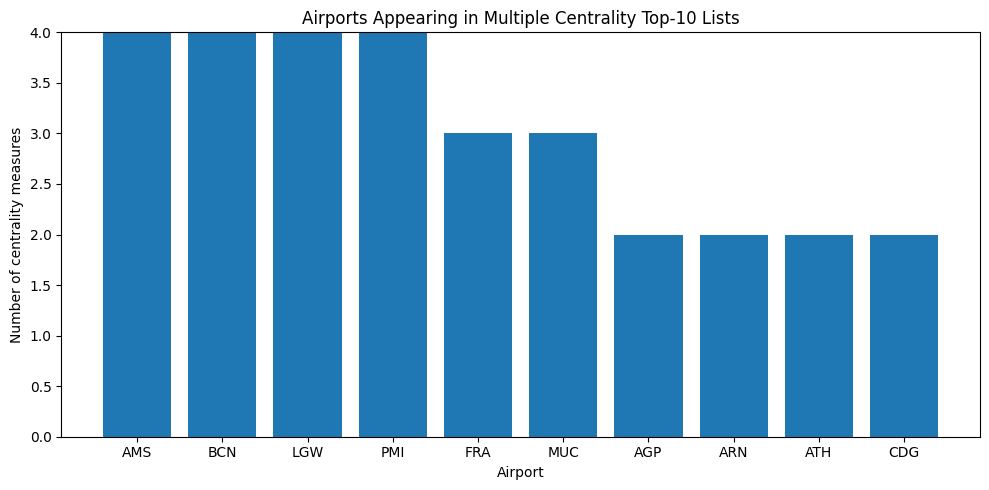

In [ ]:
overlap_plot = overlap_df.sort_values("appears_in", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    overlap_plot["airport"],
    overlap_plot["appears_in"]
)

plt.title("Airports Appearing in Multiple Centrality Top-10 Lists")
plt.xlabel("Airport")
plt.ylabel("Number of centrality measures")
plt.ylim(0, 4)
plt.tight_layout()
plt.savefig("centrality_overlap.png", dpi=300)
plt.show()

### Comparison Between Centrality Measures

The overlap between the Top-10 lists shows that some airports are central
according to several definitions, while others are important mainly in one
specific structural role.

Therefore, no single centrality measure provides a complete description of
airport importance in the network.

## 12. Comparing Route Activity with Structural Centrality

OpenFlights does not provide actual passenger volumes or flight frequencies.  
Therefore, we estimate airport activity using the total number of route records associated with each airport.

In the weighted graph, this value is represented by the weighted degree of each node:

- Regular degree counts the number of distinct airports connected to an airport.
- Weighted degree sums the weights of all edges connected to the airport and therefore represents the number of route records associated with it.

This analysis examines whether airports with high estimated route activity are also structurally central according to Degree, Betweenness, Closeness, and PageRank.

In [ ]:
# Estimate airport activity using weighted degree.
# The value represents the total number of route records associated
# with each airport in the undirected graph.

weighted_activity = dict(G_lcc.degree(weight="weight"))

activity_df = centrality_to_dataframe(
    weighted_activity,
    "route_activity"
)

activity_top10 = activity_df.head(10)

display(activity_top10)

,airport_id,route_activity,iata,name,city,country
218,1218,630,BCN,Barcelona International Airport,Barcelona,Spain
421,3998,540,PMI,Palma De Mallorca Airport,Palma de Mallorca,Spain
99,580,537,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands
14,346,506,MUC,Munich Airport,Munich,Germany
9,340,506,FRA,Frankfurt am Main Airport,Frankfurt,Germany
71,502,504,LGW,London Gatwick Airport,London,United Kingdom
276,1382,478,CDG,Charles de Gaulle International Airport,Paris,France
367,1613,469,VIE,Vienna International Airport,Vienna,Austria
60,478,447,MAN,Manchester Airport,Manchester,United Kingdom
352,1555,433,FCO,Leonardo da Vinci–Fiumicino Airport,Rome,Italy


### Comparing Activity and Centrality Rankings

The following table places the Top-10 airports by estimated route activity
beside the Top-10 rankings of the four centrality measures.

In [ ]:
activity_centrality_summary = pd.DataFrame({
    "Route Activity": activity_top10["iata"].values,
    "Degree": degree_top10["iata"].values,
    "Betweenness": betweenness_top10["iata"].values,
    "Closeness": closeness_top10["iata"].values,
    "PageRank": pagerank_top10["iata"].values
})

display(activity_centrality_summary)

,Route Activity,Degree,Betweenness,Closeness,PageRank
0,BCN,AMS,ARN,AMS,BCN
1,PMI,STN,OSL,BCN,PMI
2,AMS,MUC,ATH,LGW,ARN
3,MUC,BCN,STN,DUB,AMS
4,FRA,DUB,HEL,MUC,MUC
5,LGW,PMI,AMS,FRA,LGW
6,CDG,LGW,PMI,PMI,FRA
7,VIE,FRA,ORY,CDG,ATH
8,MAN,AGP,BCN,AGP,VIE
9,FCO,CDG,LGW,DUS,OSL


### Top-10 Overlap with Route Activity

For each centrality measure, we count how many airports also appear among
the ten airports with the highest estimated route activity.

In [ ]:
activity_top_set = set(activity_top10["iata"])

top10_overlap_with_activity = pd.DataFrame({
    "measure": [
        "Degree",
        "Betweenness",
        "Closeness",
        "PageRank"
    ],
    "common_airports": [
        len(activity_top_set.intersection(set(degree_top10["iata"]))),
        len(activity_top_set.intersection(set(betweenness_top10["iata"]))),
        len(activity_top_set.intersection(set(closeness_top10["iata"]))),
        len(activity_top_set.intersection(set(pagerank_top10["iata"])))
    ]
})

display(top10_overlap_with_activity)

,measure,common_airports
0,Degree,7
1,Betweenness,4
2,Closeness,7
3,PageRank,7


### Correlation Between Activity and Centrality

The Top-10 comparison considers only the highest-ranked airports. To compare
all airports in the largest connected component, we calculate Spearman
correlations between estimated route activity and each centrality measure.
Spearman correlation is used because the analysis compares rankings and does
not assume a linear relationship.

In [ ]:
comparison_df = pd.DataFrame({
    "airport_id": list(G_lcc.nodes()),
    "route_activity": [
        weighted_activity[node] for node in G_lcc.nodes()
    ],
    "degree_centrality": [
        degree_centrality[node] for node in G_lcc.nodes()
    ],
    "betweenness_centrality": [
        betweenness_centrality[node] for node in G_lcc.nodes()
    ],
    "closeness_centrality": [
        closeness_centrality[node] for node in G_lcc.nodes()
    ],
    "pagerank": [
        pagerank[node] for node in G_lcc.nodes()
    ]
})

spearman_correlations = (
    comparison_df[
        [
            "route_activity",
            "degree_centrality",
            "betweenness_centrality",
            "closeness_centrality",
            "pagerank"
        ]
    ]
    .corr(method="spearman")
    .loc["route_activity"]
    .drop("route_activity")
    .sort_values(ascending=False)
)

spearman_correlations_df = (
    spearman_correlations
    .rename("spearman_correlation")
    .reset_index()
    .rename(columns={"index": "centrality_measure"})
)

display(spearman_correlations_df)

,centrality_measure,spearman_correlation
0,degree_centrality,0.985765
1,pagerank,0.942725
2,closeness_centrality,0.923004
3,betweenness_centrality,0.893946


### Visual Comparison of Route Activity and Centrality

The following scatter plots illustrate the relationship between estimated
route activity and two different structural roles. Degree reflects the
number of direct connections, while Betweenness reflects the role of an
airport on shortest paths between other airports.

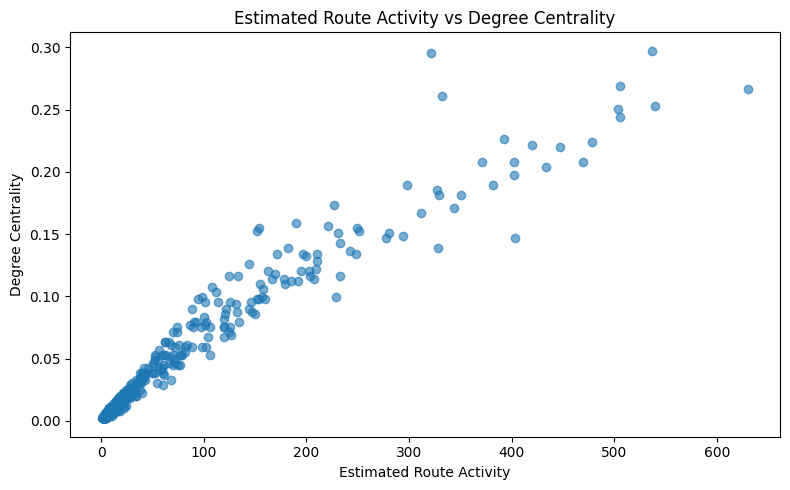

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    comparison_df["route_activity"],
    comparison_df["degree_centrality"],
    alpha=0.6
)

plt.title("Estimated Route Activity vs Degree Centrality")
plt.xlabel("Estimated Route Activity")
plt.ylabel("Degree Centrality")
plt.tight_layout()
plt.show()

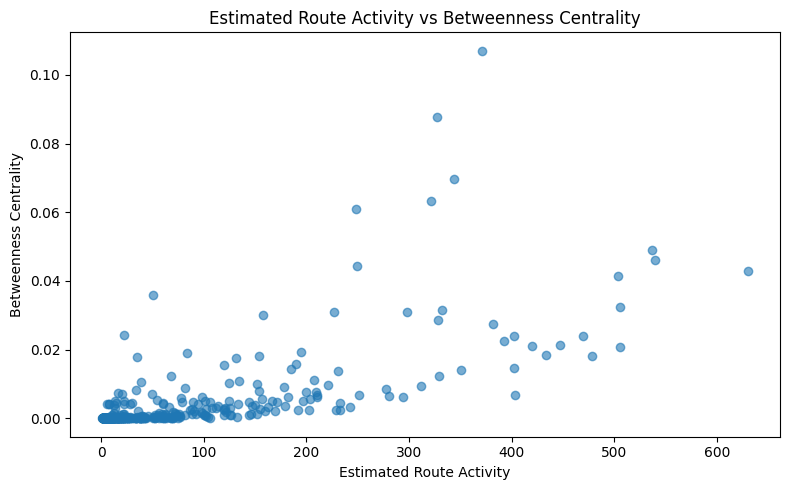

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    comparison_df["route_activity"],
    comparison_df["betweenness_centrality"],
    alpha=0.6
)

plt.title("Estimated Route Activity vs Betweenness Centrality")
plt.xlabel("Estimated Route Activity")
plt.ylabel("Betweenness Centrality")
plt.tight_layout()
plt.show()

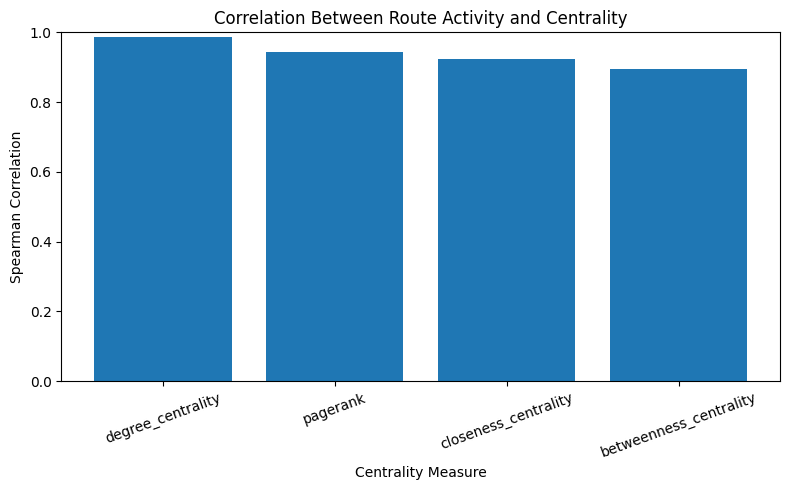

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    spearman_correlations_df["centrality_measure"],
    spearman_correlations_df["spearman_correlation"]
)

plt.title("Correlation Between Route Activity and Centrality")
plt.xlabel("Centrality Measure")
plt.ylabel("Spearman Correlation")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Conclusion: Route Activity and Structural Centrality

The results show that estimated route activity is strongly associated with
structural centrality. Airports with many documented route records usually
also have many direct connections, high accessibility, and connections to
other important airports.

The strongest relationship was found with Degree Centrality
(Spearman correlation = 0.986), while Betweenness Centrality showed the
lowest, although still strong, relationship (0.894).

The Top-10 comparison supports this finding: 7 of the 10 most active
airports also appear in the Top-10 lists of Degree, Closeness, and PageRank,
whereas only 4 appear in the Top-10 Betweenness list.

This indicates that activity and centrality are closely related, but they
are not identical. In particular, Betweenness captures a different role:
an airport may function as an important bridge between parts of the network
without having one of the highest activity levels.

Therefore, estimated activity alone is not sufficient for identifying all
structurally important airports.

## 13. Local Clustering and Structural Roles

The local clustering coefficient measures how strongly the neighbors of an
airport are connected to one another.

This adds a local perspective that is not captured directly by the centrality
measures. Two airports may have a similar degree, but one may be located inside
a densely connected group, while the other may connect destinations that are
not strongly connected to each other.

The analysis examines:

- The average clustering coefficient of the network.
- The clustering coefficient of highly connected airports.
- The relationship between Degree, Betweenness, and local clustering.
- Airports that combine high centrality with low local clustering.

In [ ]:
# Calculate the local clustering coefficient for every airport
clustering_coefficients = nx.clustering(G_lcc)

average_clustering = nx.average_clustering(G_lcc)

print(
    f"Average local clustering coefficient: "
    f"{average_clustering:.4f}"
)

Average local clustering coefficient: 0.4509


### Combining Clustering and Centrality Measures

A combined table is created for every airport in the largest connected
component. It includes degree, Degree Centrality, Betweenness Centrality,
and the local clustering coefficient, allowing the relationships between
these measures to be examined.

In [ ]:
clustering_df = pd.DataFrame({
    "airport_id": list(G_lcc.nodes()),
    "degree": [
        G_lcc.degree(node)
        for node in G_lcc.nodes()
    ],
    "degree_centrality": [
        degree_centrality[node]
        for node in G_lcc.nodes()
    ],
    "betweenness_centrality": [
        betweenness_centrality[node]
        for node in G_lcc.nodes()
    ],
    "clustering_coefficient": [
        clustering_coefficients[node]
        for node in G_lcc.nodes()
    ]
})

clustering_df = clustering_df.merge(
    active_europe_airports[
        ["airport_id", "iata", "name", "city", "country"]
    ],
    on="airport_id",
    how="left"
)

clustering_df = clustering_df.sort_values(
    by="degree",
    ascending=False
)

display(
    clustering_df[
        [
            "iata",
            "name",
            "country",
            "degree",
            "betweenness_centrality",
            "clustering_coefficient"
        ]
    ].head(15)
)

,iata,name,country,degree,betweenness_centrality,clustering_coefficient
99,AMS,Amsterdam Airport Schiphol,Netherlands,146,0.048899,0.247048
97,STN,London Stansted Airport,United Kingdom,145,0.063192,0.132759
14,MUC,Munich Airport,Germany,132,0.032488,0.258501
218,BCN,Barcelona International Airport,Spain,131,0.042983,0.271051
105,DUB,Dublin Airport,Ireland,128,0.031586,0.279528
421,PMI,Palma De Mallorca Airport,Spain,124,0.046027,0.194860
71,LGW,London Gatwick Airport,United Kingdom,123,0.041586,0.230041
9,FRA,Frankfurt am Main Airport,Germany,120,0.020804,0.271849
227,AGP,Málaga Airport,Spain,111,0.022455,0.262572
276,CDG,Charles de Gaulle International Airport,France,110,0.018136,0.313428


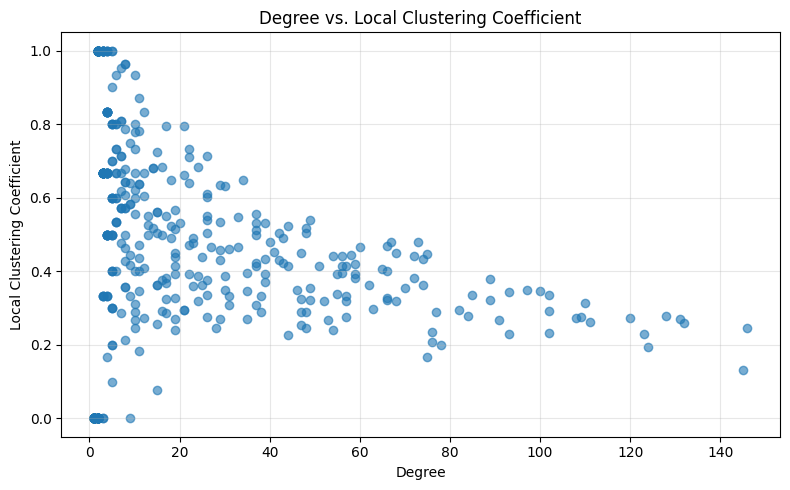

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clustering_df["degree"],
    clustering_df["clustering_coefficient"],
    alpha=0.6
)

plt.title("Degree vs. Local Clustering Coefficient")
plt.xlabel("Degree")
plt.ylabel("Local Clustering Coefficient")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Correlations with Local Clustering

Spearman correlations are calculated to examine whether airports with high
Degree or high Betweenness tend to have higher or lower local clustering
coefficients.

In [ ]:
clustering_correlations = (
    clustering_df[
        [
            "degree",
            "betweenness_centrality",
            "clustering_coefficient"
        ]
    ]
    .corr(method="spearman")
)

display(clustering_correlations)

,degree,betweenness_centrality,clustering_coefficient
degree,1.000000,0.902634,0.093804
betweenness_centrality,0.902634,1.000000,-0.121078
clustering_coefficient,0.093804,-0.121078,1.000000


### Exploratory Hub-Bridge Candidates

The hub-bridge candidates are identified using an exploratory rule defined
for this project: airports in the upper quartile of Degree and Betweenness
and the lower quartile of local clustering.

This is not a standard centrality measure, but a project-specific way to
identify airports that combine broad connectivity, bridge importance, and
low local cohesion.

In [ ]:
degree_threshold = clustering_df["degree"].quantile(0.75)

betweenness_threshold = clustering_df[
    "betweenness_centrality"
].quantile(0.75)

clustering_threshold = clustering_df[
    "clustering_coefficient"
].quantile(0.25)

hub_bridge_candidates = clustering_df[
    (clustering_df["degree"] >= degree_threshold) &
    (
        clustering_df["betweenness_centrality"] >=
        betweenness_threshold
    ) &
    (
        clustering_df["clustering_coefficient"] <=
        clustering_threshold
    )
].sort_values(
    by=["betweenness_centrality", "degree"],
    ascending=False
)

display(
    hub_bridge_candidates[
        [
            "iata",
            "name",
            "country",
            "degree",
            "betweenness_centrality",
            "clustering_coefficient"
        ]
    ]
)

,iata,name,country,degree,betweenness_centrality,clustering_coefficient
185,ARN,Stockholm-Arlanda Airport,Sweden,102,0.107063,0.233159
97,STN,London Stansted Airport,United Kingdom,145,0.063192,0.132759
99,AMS,Amsterdam Airport Schiphol,Netherlands,146,0.048899,0.247048
421,PMI,Palma De Mallorca Airport,Spain,124,0.046027,0.194860
277,ORY,Paris-Orly Airport,France,76,0.044409,0.207018
71,LGW,London Gatwick Airport,United Kingdom,123,0.041586,0.230041
214,ALC,Alicante International Airport,Spain,93,0.030914,0.228378
339,BGY,Il Caravaggio International Airport,Italy,76,0.018269,0.235789
65,LTN,London Luton Airport,United Kingdom,78,0.015821,0.200466
3,CRL,Brussels South Charleroi Airport,Belgium,75,0.010097,0.167207


### Interpretation of Local Clustering Results

The average local clustering coefficient is 0.4509, indicating a moderate
level of local connectivity among neighboring airports.

The Spearman correlation between Degree and local clustering is 0.094,
showing almost no monotonic relationship between the number of direct
connections of an airport and the connectivity among its neighbors.

The correlation between Betweenness and local clustering is weakly negative
(-0.121). This suggests that airports serving as structural bridges may
sometimes have less densely connected neighborhoods, although the relationship
is weak.

The exploratory hub-bridge analysis identifies airports that combine high
Degree, high Betweenness, and low local clustering. These airports may connect
many destinations while also linking parts of the network that are not strongly
connected to one another.

## 14. Community Detection Using Louvain

The Louvain algorithm is applied to the largest connected component in order
to identify groups of airports that are more densely connected internally
than with the rest of the network.

The analysis examines:

- The number and size of detected communities.
- The modularity of the partition.
- The geographic composition of each community.
- Airports that connect different communities.

In [ ]:
# Detect communities using the Louvain algorithm.
# Edge weights are included so that repeated route records
# influence the detected community structure.

louvain_partition = community_louvain.best_partition(
    G_lcc,
    weight="weight",
    random_state=42
)

num_communities = len(set(louvain_partition.values()))

modularity_score = community_louvain.modularity(
    louvain_partition,
    G_lcc,
    weight="weight"
)

print("Number of communities:", num_communities)
print("Modularity:", round(modularity_score, 4))

Number of communities: 8
Modularity: 0.2527


### Network Visualization by Louvain Community

The following visualization presents the largest connected component of the
European flight network. Each node represents an airport, each color represents
a Louvain community, and node size reflects Degree Centrality.

Only selected structurally prominent airports are labeled in order to keep
the visualization readable. The layout uses a fixed random seed so that it
remains consistent across runs.

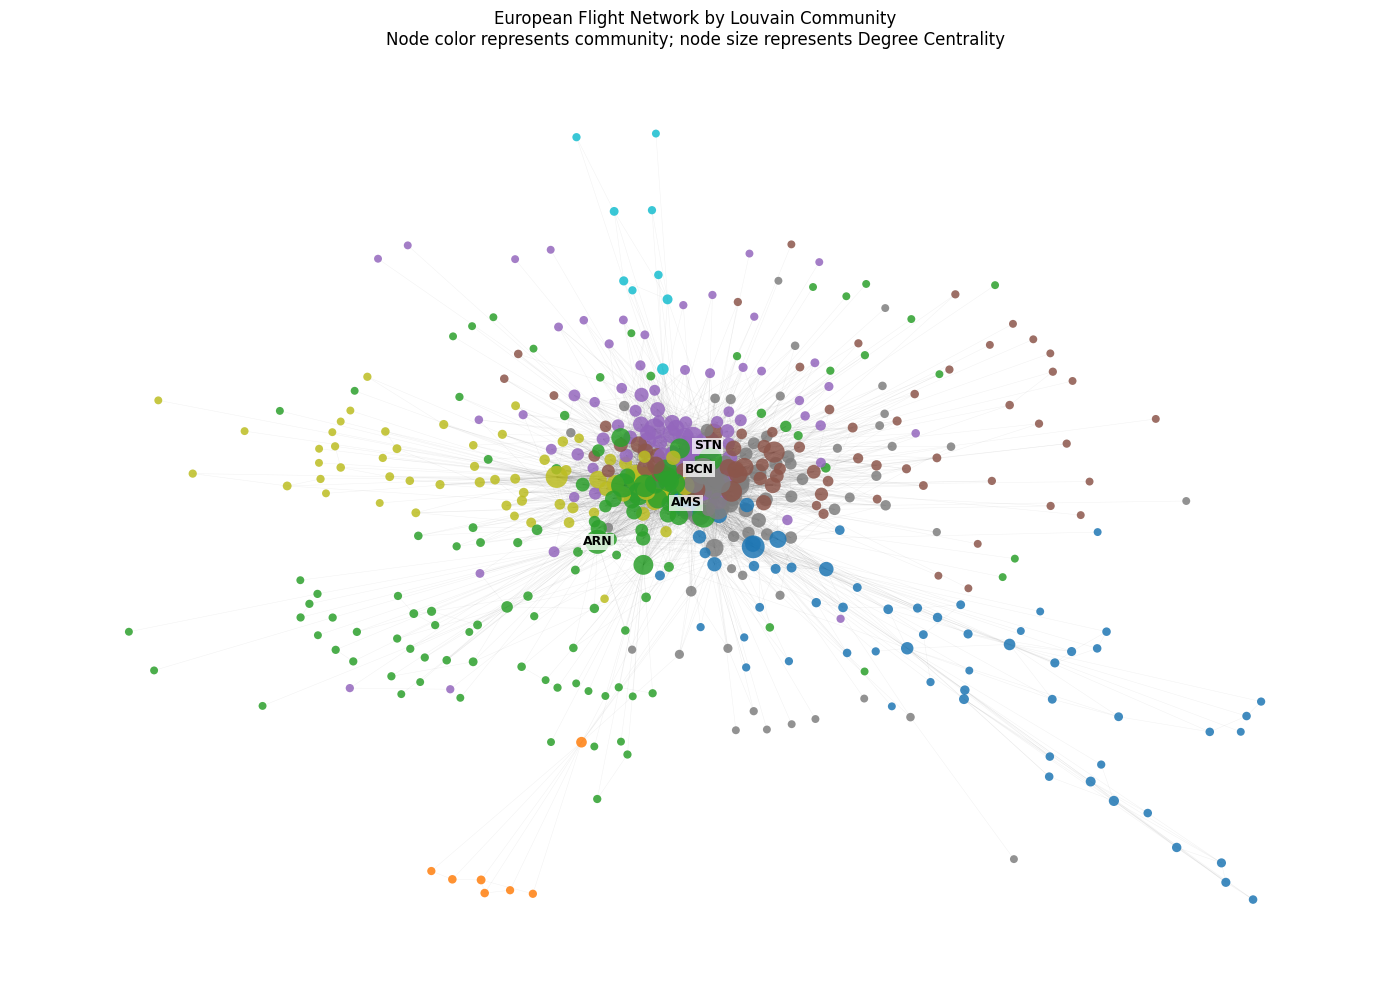

In [ ]:
# Create a fixed layout so that the visualization is reproducible.
network_position = nx.spring_layout(
    G_lcc,
    seed=42,
    weight="weight",
    k=0.22,
    iterations=100
)

# Assign each node its Louvain community.
node_communities = [
    louvain_partition[node]
    for node in G_lcc.nodes()
]

# Scale node size according to Degree Centrality.
node_sizes = [
    30 + 1300 * degree_centrality[node]
    for node in G_lcc.nodes()
]

plt.figure(figsize=(14, 10))

# Draw edges lightly so the overall structure remains visible.
nx.draw_networkx_edges(
    G_lcc,
    network_position,
    alpha=0.05,
    width=0.4
)

# Draw nodes by community and Degree Centrality.
nx.draw_networkx_nodes(
    G_lcc,
    network_position,
    node_color=node_communities,
    node_size=node_sizes,
    cmap=plt.cm.tab10,
    alpha=0.85,
    linewidths=0
)

# Label only a small number of prominent airports.
airports_to_label = {
    airport_id: iata
    for airport_id, iata in zip(
        airports["airport_id"],
        airports["iata"]
    )
    if iata in {"AMS", "STN", "ARN", "BCN"}
    and airport_id in G_lcc
}

nx.draw_networkx_labels(
    G_lcc,
    network_position,
    labels=airports_to_label,
    font_size=9,
    font_weight="bold",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.75,
        pad=1
    )
)

plt.title(
    "European Flight Network by Louvain Community\n"
    "Node color represents community; node size represents Degree Centrality"
)

plt.axis("off")
plt.tight_layout()
plt.show()

### Interpretation of the Network Visualization

The visualization shows several partially separated communities, while many
connections still exist between them. This is consistent with the modularity
score of 0.2527, which indicates a detectable but not strongly separated
community structure.

Larger nodes represent airports with high Degree Centrality. Several major
airports also appear close to connections between differently colored groups,
illustrating their role in cross-community connectivity.

The node positions are determined by the network layout and should not be
interpreted as geographic locations.

### Community Sizes

After applying Louvain, we count the number of airports assigned to each
community. This shows whether the detected partition contains similarly sized
groups or a combination of large and small communities.

In [ ]:
community_sizes = (
    pd.Series(louvain_partition)
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis("community")
    .reset_index(name="number_of_airports")
)

display(community_sizes)

,community,number_of_airports
0,2,123
1,3,79
2,5,78
3,4,71
4,6,64
5,0,61
6,7,9
7,1,7


### Community Size Visualization

The following bar chart shows the number of airports assigned to each
Louvain community. It makes it easier to compare the relative sizes of the
detected communities and identify particularly large or small groups.

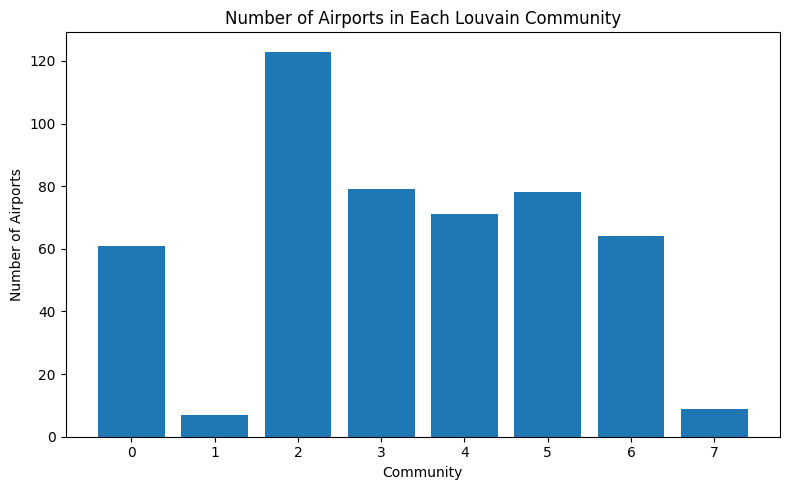

In [ ]:
community_sizes_plot = community_sizes.sort_values(
    "community"
)

plt.figure(figsize=(8, 5))

plt.bar(
    community_sizes_plot["community"].astype(str),
    community_sizes_plot["number_of_airports"]
)

plt.title("Number of Airports in Each Louvain Community")
plt.xlabel("Community")
plt.ylabel("Number of Airports")
plt.tight_layout()
plt.show()

### Linking Airports to Their Communities

The following table links each airport to its Louvain community and adds
airport metadata. It is used to examine the countries and airports represented
in each detected community.

In [ ]:
# Create a table that links every airport to its detected community.

community_airports_df = pd.DataFrame({
    "airport_id": list(louvain_partition.keys()),
    "community": list(louvain_partition.values())
})

community_airports_df = community_airports_df.merge(
    airports[
        [
            "airport_id",
            "iata",
            "name",
            "city",
            "country"
        ]
    ],
    on="airport_id",
    how="left"
)

display(community_airports_df.head())

,airport_id,community,iata,name,city,country
0,16,0,KEF,Keflavik International Airport,Keflavik,Iceland
1,299,4,ANR,Antwerp International Airport (Deurne),Antwerp,Belgium
2,302,2,BRU,Brussels Airport,Brussels,Belgium
3,304,3,CRL,Brussels South Charleroi Airport,Charleroi,Belgium
4,309,4,LGG,Liège Airport,Liege,Belgium


### Geographic Composition of the Communities

For each community, we count how many airports belong to each country. This
helps determine whether the communities have a clear geographic pattern or
combine airports from several countries.

In [ ]:
community_country_counts = (
    community_airports_df
    .groupby(["community", "country"])
    .size()
    .reset_index(name="number_of_airports")
    .sort_values(
        ["community", "number_of_airports"],
        ascending=[True, False]
    )
)

top_countries_per_community = (
    community_country_counts
    .groupby("community")
    .head(5)
)

display(top_countries_per_community)

,community,country,number_of_airports
4,0,Norway,47
7,0,United Kingdom,5
0,0,Denmark,4
1,0,Faroe Islands,1
2,0,Iceland,1
8,1,United Kingdom,7
35,2,Sweden,29
19,2,Finland,17
34,2,Spain,15
37,2,Ukraine,8


### Central Airports Within Each Community

Degree Centrality is added to the community table in order to identify the
most highly connected airports within each detected community.

In [ ]:
community_airports_df["degree_centrality"] = (
    community_airports_df["airport_id"]
    .map(degree_centrality)
)

top_airports_per_community = (
    community_airports_df
    .sort_values(
        ["community", "degree_centrality"],
        ascending=[True, False]
    )
    .groupby("community")
    .head(5)
    [
        [
            "community",
            "iata",
            "name",
            "city",
            "country",
            "degree_centrality"
        ]
    ]
)

display(top_airports_per_community)

,community,iata,name,city,country,degree_centrality
99,0,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,0.297352
132,0,OSL,Oslo Lufthavn,Oslo,Norway,0.185336
125,0,BGO,Bergen Airport Flesland,Bergen,Norway,0.093686
111,0,BLL,Billund Airport,Billund,Denmark,0.075356
150,0,SVG,Stavanger Airport Sola,Stavanger,Norway,0.075356
83,1,KOI,Kirkwall Airport,Kirkwall,United Kingdom,0.022403
448,1,NRL,North Ronaldsay Airport,North Ronaldsay,United Kingdom,0.008147
449,1,PPW,Papa Westray Airport,Papa Westray,United Kingdom,0.006110
451,1,NDY,Sanday Airport,Sanday,United Kingdom,0.006110
447,1,EOI,Eday Airport,Eday,United Kingdom,0.004073


### Interpretation of the Detected Communities

The Louvain algorithm detected eight communities with a modularity score
of 0.2527. This indicates the presence of community structure, although
the separation between communities is not very strong.

Some communities have a clear geographic interpretation. For example,
one community is dominated by Norwegian airports, while the smaller
communities represent the Orkney Islands and the Azores.

Other communities combine airports from several countries. These groups
appear to reflect not only geographic proximity, but also recurring route
patterns between major hubs, tourism destinations, and secondary airports.

For example, one community contains many airports from the United Kingdom
and Spain, including LGW, MAN, PMI, AGP, and ALC. This may reflect strong
travel connections between the United Kingdom and Spanish tourism
destinations.

Therefore, the detected communities represent a combination of geographic
regions and operational route patterns rather than a strict division by
country.

### Cross-Community Connections

For each airport, cross-community connections are counted as the number of
distinct neighboring airports that belong to other communities.

Edge weights are not summed in this analysis. Therefore, the value represents
the number of different external airport connections, rather than the number
of route records.

In [ ]:
# Count internal and cross-community connections for each airport.

bridge_rows = []

for airport in G_lcc.nodes():
    airport_community = louvain_partition[airport]

    internal_edges = 0
    external_edges = 0
    connected_communities = set()

    for neighbor in G_lcc.neighbors(airport):
        neighbor_community = louvain_partition[neighbor]

        if neighbor_community == airport_community:
            internal_edges += 1
        else:
            external_edges += 1
            connected_communities.add(neighbor_community)

    total_edges = internal_edges + external_edges

    bridge_rows.append({
        "airport_id": airport,
        "community": airport_community,
        "internal_connections": internal_edges,
        "cross_community_connections": external_edges,
        "connected_other_communities": len(connected_communities),
        "cross_community_ratio":
            external_edges / total_edges if total_edges > 0 else 0
    })

bridge_df = pd.DataFrame(bridge_rows)

### Adding Airport Information to the Cross-Community Results

Airport metadata and Betweenness scores are added to the cross-community
connection table so that the leading airports can be identified and compared.

In [ ]:
bridge_df = bridge_df.merge(
    airports[
        [
            "airport_id",
            "iata",
            "name",
            "city",
            "country"
        ]
    ],
    on="airport_id",
    how="left"
)

bridge_df["betweenness_centrality"] = (
    bridge_df["airport_id"].map(betweenness_centrality)
)

### Ranking Cross-Community Airports

Airports are ranked by the number of distinct neighbors located in other
communities. The table also shows how many different communities each airport
reaches directly and its Betweenness score.

In [ ]:
top_cross_community_airports = (
    bridge_df
    .sort_values(
        [
            "cross_community_connections",
            "connected_other_communities",
            "betweenness_centrality"
        ],
        ascending=False
    )
    .head(15)
    [
        [
            "iata",
            "name",
            "country",
            "community",
            "cross_community_connections",
            "connected_other_communities",
            "cross_community_ratio",
            "betweenness_centrality"
        ]
    ]
)

display(top_cross_community_airports)

,iata,name,country,community,cross_community_connections,connected_other_communities,cross_community_ratio,betweenness_centrality
99,AMS,Amsterdam Airport Schiphol,Netherlands,0,131,6,0.897260,0.048899
14,MUC,Munich Airport,Germany,6,100,5,0.757576,0.032488
218,BCN,Barcelona International Airport,Spain,2,95,5,0.725191,0.042983
105,DUB,Dublin Airport,Ireland,3,94,5,0.734375,0.031586
97,STN,London Stansted Airport,United Kingdom,3,91,5,0.627586,0.063192
71,LGW,London Gatwick Airport,United Kingdom,5,90,6,0.731707,0.041586
9,FRA,Frankfurt am Main Airport,Germany,2,84,6,0.700000,0.020804
276,CDG,Charles de Gaulle International Airport,France,4,83,5,0.754545,0.018136
421,PMI,Palma De Mallorca Airport,Spain,5,82,5,0.661290,0.046027
13,DUS,Düsseldorf Airport,Germany,6,80,6,0.733945,0.021195


### Airports Connecting Different Communities

The analysis shows that several major airports maintain direct connections
to many airports outside their own detected community.

AMS has the highest number of cross-community connections, with direct
connections to 131 distinct airports across six other communities. MUC, BCN,
DUB, STN, and LGW also maintain direct connections to many airports outside
their own communities.

However, the number of cross-community connections is not identical to
Betweenness Centrality. For example, STN has fewer cross-community connections
than AMS, but a higher Betweenness score. This indicates that STN lies on a
larger proportion of shortest paths, while AMS has a broader set of direct
connections across communities.

Therefore, airports can connect communities in different ways: some act as
broad hubs with many external airport connections, while others serve as more
critical bridges along shortest paths.

## 15. Network Robustness Experiments

The robustness of the European flight network is evaluated by gradually
removing airports and measuring the resulting damage to network connectivity.

Four removal strategies are compared:

- Random removal
- Removal by Degree Centrality
- Removal by Betweenness Centrality
- Removal by PageRank

The centrality rankings are calculated once before the experiment and remain
fixed throughout the removal process.

After each removal stage, the following measures are calculated:

- Size of the largest connected component
- Fraction of the remaining airports in the largest connected component
- Fraction of the original network contained in the largest connected component
- Number of connected components

In [ ]:
def calculate_network_state(graph, original_number_of_nodes):
    """
    Calculate connectivity measures for the current graph.
    """

    remaining_nodes = graph.number_of_nodes()

    if remaining_nodes == 0:
        return {
            "remaining_nodes": 0,
            "largest_component_size": 0,
            "largest_component_fraction_remaining": 0,
            "largest_component_fraction_original": 0,
            "number_of_components": 0
        }

    components = list(nx.connected_components(graph))
    largest_component_size = max(
        len(component)
        for component in components
    )

    return {
        "remaining_nodes": remaining_nodes,
        "largest_component_size": largest_component_size,

        # Fraction of the airports that remain after removal
        "largest_component_fraction_remaining":
            largest_component_size / remaining_nodes,

        # Fraction of the original network
        "largest_component_fraction_original":
            largest_component_size / original_number_of_nodes,

        "number_of_components": len(components)
    }

### Removal Stages

The experiments evaluate the network after removing increasing percentages
of airports, from 0% to 30% of the original largest connected component.

In [ ]:
removal_percentages = [
    0,
    1,
    2,
    5,
    10,
    15,
    20,
    25,
    30
]

### Static Targeted Removal Rankings

For each targeted strategy, airports are sorted once according to their
original Degree, Betweenness, or PageRank score. These rankings remain fixed
throughout the experiment and are not recalculated after each removal stage.

In [ ]:
degree_removal_order = [
    node for node, score in sorted(
        degree_centrality.items(),
        key=lambda item: item[1],
        reverse=True
    )
]

betweenness_removal_order = [
    node for node, score in sorted(
        betweenness_centrality.items(),
        key=lambda item: item[1],
        reverse=True
    )
]

pagerank_removal_order = [
    node for node, score in sorted(
        pagerank.items(),
        key=lambda item: item[1],
        reverse=True
    )
]

### Running the Targeted Removal Experiments

This function removes the highest-ranked airports according to a fixed
centrality ranking. After each removal percentage, it measures the size of
the largest connected component, its fraction of the remaining and original
network, and the number of connected components.

In [ ]:
def run_static_removal_experiment(
    graph,
    removal_order,
    removal_percentages,
    strategy_name
):
    """
    Remove nodes according to a fixed ranking and measure
    the network state after each removal percentage.
    """

    original_number_of_nodes = graph.number_of_nodes()
    results = []

    for percentage in removal_percentages:
        number_to_remove = round(
            original_number_of_nodes * percentage / 100
        )

        graph_copy = graph.copy()

        nodes_to_remove = removal_order[:number_to_remove]
        graph_copy.remove_nodes_from(nodes_to_remove)

        state = calculate_network_state(
            graph_copy,
            original_number_of_nodes
        )

        results.append({
            "strategy": strategy_name,
            "removed_percentage": percentage,
            "removed_nodes": number_to_remove,
            "remaining_nodes": state["remaining_nodes"],
            "largest_component_size": state[
                "largest_component_size"
            ],
            "largest_component_fraction_remaining": state[
                "largest_component_fraction_remaining"
            ],
            "largest_component_fraction_original": state[
                "largest_component_fraction_original"
            ],
            "number_of_components": state[
                "number_of_components"
            ]
        })

    return pd.DataFrame(results)

### Applying the Three Targeted Strategies

The static experiment is now run separately using the Degree, Betweenness,
and PageRank removal rankings.

In [ ]:
degree_robustness = run_static_removal_experiment(
    G_lcc,
    degree_removal_order,
    removal_percentages,
    "Degree"
)

betweenness_robustness = run_static_removal_experiment(
    G_lcc,
    betweenness_removal_order,
    removal_percentages,
    "Betweenness"
)

pagerank_robustness = run_static_removal_experiment(
    G_lcc,
    pagerank_removal_order,
    removal_percentages,
    "PageRank"
)

targeted_robustness_results = pd.concat(
    [
        degree_robustness,
        betweenness_robustness,
        pagerank_robustness
    ],
    ignore_index=True
)

display(targeted_robustness_results)

,strategy,removed_percentage,removed_nodes,remaining_nodes,largest_component_size,largest_component_fraction_remaining,largest_component_fraction_original,number_of_components
0,Degree,0,0,492,492,1.000000,1.000000,1
1,Degree,1,5,487,482,0.989733,0.979675,6
2,Degree,2,10,482,474,0.983402,0.963415,9
3,Degree,5,25,467,427,0.914347,0.867886,38
4,Degree,10,49,443,368,0.830700,0.747967,70
5,Degree,15,74,418,311,0.744019,0.632114,99
6,Degree,20,98,394,240,0.609137,0.487805,127
7,Degree,25,123,369,115,0.311653,0.233740,178
8,Degree,30,148,344,28,0.081395,0.056911,208
9,Betweenness,0,0,492,492,1.000000,1.000000,1


### Random Removal Experiment

For every removal percentage, this function selects airports randomly and
repeats the experiment 30 times. The reported values are averages across the
repetitions, reducing dependence on one random selection.

In [ ]:
def run_random_removal_experiment(
    graph,
    removal_percentages,
    repetitions=30,
    random_seed=42
):
    """
    Randomly remove nodes several times for each removal percentage
    and return the average network state.
    """

    random.seed(random_seed)

    all_nodes = list(graph.nodes())
    original_number_of_nodes = graph.number_of_nodes()

    results = []

    for percentage in removal_percentages:
        number_to_remove = round(
            original_number_of_nodes * percentage / 100
        )

        repetition_results = []

        for repetition in range(repetitions):
            graph_copy = graph.copy()

            nodes_to_remove = random.sample(
                all_nodes,
                number_to_remove
            )

            graph_copy.remove_nodes_from(nodes_to_remove)

            state = calculate_network_state(
                graph_copy,
                original_number_of_nodes
            )

            repetition_results.append(state)

        results.append({
            "strategy": "Random",
            "removed_percentage": percentage,
            "removed_nodes": number_to_remove,

            "remaining_nodes": np.mean([
                result["remaining_nodes"]
                for result in repetition_results
            ]),

            "largest_component_size": np.mean([
                result["largest_component_size"]
                for result in repetition_results
            ]),

            "largest_component_fraction_remaining": np.mean([
                result["largest_component_fraction_remaining"]
                for result in repetition_results
            ]),

            "largest_component_fraction_original": np.mean([
                result["largest_component_fraction_original"]
                for result in repetition_results
            ]),

            "number_of_components": np.mean([
                result["number_of_components"]
                for result in repetition_results
            ])
        })

    return pd.DataFrame(results)

### Running the Random Removal Strategy

The random removal experiment is executed with 30 repetitions for each
removal percentage. The resulting table reports the average connectivity
measures across the repetitions.

In [ ]:
random_robustness = run_random_removal_experiment(
    G_lcc,
    removal_percentages,
    repetitions=30,
    random_seed=42
)

display(random_robustness)

,strategy,removed_percentage,removed_nodes,remaining_nodes,largest_component_size,largest_component_fraction_remaining,largest_component_fraction_original,number_of_components
0,Random,0,0,492.0,492.000000,1.000000,1.000000,1.000000
1,Random,1,5,487.0,485.333333,0.996578,0.986450,2.166667
2,Random,2,10,482.0,479.666667,0.995159,0.974932,3.000000
3,Random,5,25,467.0,462.733333,0.990864,0.940515,4.866667
4,Random,10,49,443.0,434.466667,0.980737,0.883062,8.933333
5,Random,15,74,418.0,407.066667,0.973844,0.827371,10.766667
6,Random,20,98,394.0,379.500000,0.963198,0.771341,13.966667
7,Random,25,123,369.0,346.333333,0.938573,0.703930,20.266667
8,Random,30,148,344.0,317.900000,0.924128,0.646138,23.966667


### Combining the Robustness Results

The random and targeted experiment results are combined into one table so
that all four removal strategies can be compared at the same removal stages.

In [ ]:
all_robustness_results = pd.concat(
    [
        targeted_robustness_results,
        random_robustness
    ],
    ignore_index=True
)

display(all_robustness_results)

,strategy,removed_percentage,removed_nodes,remaining_nodes,largest_component_size,largest_component_fraction_remaining,largest_component_fraction_original,number_of_components
0,Degree,0,0,492.0,492.000000,1.000000,1.000000,1.000000
1,Degree,1,5,487.0,482.000000,0.989733,0.979675,6.000000
2,Degree,2,10,482.0,474.000000,0.983402,0.963415,9.000000
3,Degree,5,25,467.0,427.000000,0.914347,0.867886,38.000000
4,Degree,10,49,443.0,368.000000,0.830700,0.747967,70.000000
5,Degree,15,74,418.0,311.000000,0.744019,0.632114,99.000000
6,Degree,20,98,394.0,240.000000,0.609137,0.487805,127.000000
7,Degree,25,123,369.0,115.000000,0.311653,0.233740,178.000000
8,Degree,30,148,344.0,28.000000,0.081395,0.056911,208.000000
9,Betweenness,0,0,492.0,492.000000,1.000000,1.000000,1.000000


### Robustness Comparison

The following plots compare the damage caused by the four strategies. A
smaller largest connected component and a larger number of components indicate
greater fragmentation of the network.

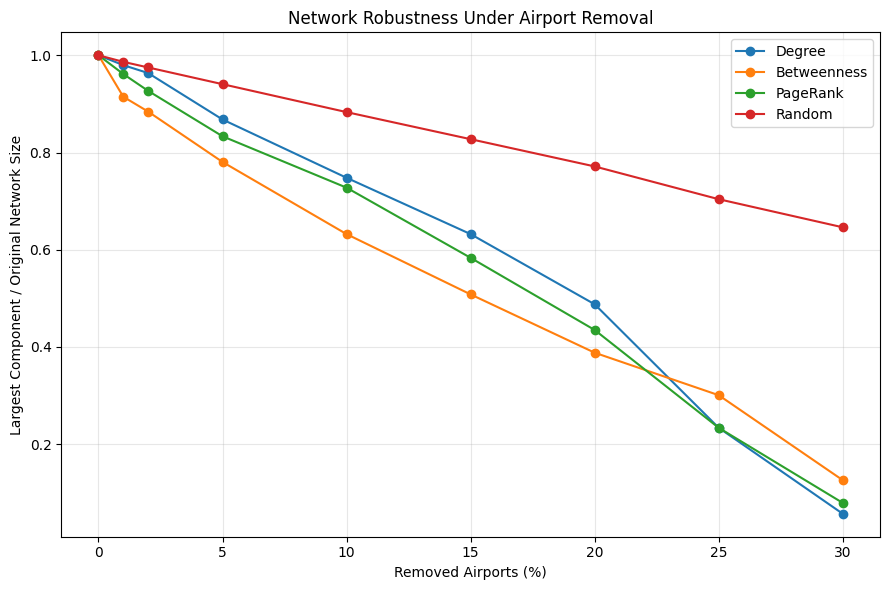

In [ ]:
plt.figure(figsize=(9, 6))

for strategy in all_robustness_results["strategy"].unique():
    strategy_data = all_robustness_results[
        all_robustness_results["strategy"] == strategy
    ]

    plt.plot(
        strategy_data["removed_percentage"],
        strategy_data["largest_component_fraction_original"],
        marker="o",
        label=strategy
    )

plt.title("Network Robustness Under Airport Removal")
plt.xlabel("Removed Airports (%)")
plt.ylabel("Largest Component / Original Network Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of the Robustness Experiments

The results show that the European flight network is relatively robust to
random airport removal but substantially more vulnerable to targeted removal.

After randomly removing 30% of the airports, the largest connected component
still contains approximately 64.6% of the airports in the original network.
In contrast, after removing 30% of the airports according to Degree,
Betweenness, or PageRank, the largest connected component contains only
approximately 5.7%, 12.6%, and 7.9% of the original airports, respectively.

Betweenness-based removal causes the strongest damage during the early and
intermediate stages of the experiment. For example, after removing 20% of the
airports according to Betweenness, the largest connected component contains
approximately 38.8% of the original network. This supports the interpretation
that high-Betweenness airports serve as important bridges between different
parts of the network.

At the 30% removal stage, Degree-based removal produces the smallest largest
connected component. This indicates that removing a large proportion of the
main hubs eventually causes severe fragmentation of the network.

Overall, the network is resilient to random failures but highly sensitive to
targeted removal of structurally central airports.

## 16. Final Conclusions

The European flight network contains one dominant connected component, but
airport importance cannot be described using a single measure.

Estimated route activity is strongly associated with Degree, Closeness, and
PageRank, while Betweenness identifies a different structural role related to
bridges between parts of the network. Local clustering further shows that
airports with similar numbers of direct connections may have different local
neighborhood structures.

The Louvain algorithm detected both geographically concentrated communities
and communities that span several countries. The cross-community analysis
showed that airports may connect communities either through many direct
external connections or by occupying important positions on shortest paths.

Finally, the robustness experiments showed that the network is considerably
more resilient to random airport removal than to targeted removal of central
airports.

Overall, activity, centrality, local cohesion, community structure, and
robustness provide complementary perspectives on the structural importance
of airports in the European flight network.